In [1]:
# ============================================================
#  Profit-Vorhersage im Global-Superstore-Datensatz
#  Projektarbeit ADS-04 Machine Learning — reine Code-Fassung
#
#  Diese Datei enthaelt ausschliesslich den Code.
#  Die kommentierte Fassung mit allen Erlaeuterungen und
#  Befunden steht in ADS04_Gesamtanalyse.ipynb.
# ============================================================
# ----------------------------------------------------------
#  TEIL 01 — Datenaufbereitung
# ----------------------------------------------------------

%matplotlib inline
# Grafiken direkt im Notebook anzeigen
# ▶️ DIESE ZELLE IMMER ZUERST AUSFÜHREN — richtet die Pfade ein und prüft die Umgebung
import sys, os, importlib

if "google.colab" in sys.modules:                       # Sonderfall Google Colab
    from google.colab import drive; drive.mount("/content/drive")
    p = "/content/drive/MyDrive/ADS04-Abgabe/notebooks"
    if os.path.isdir(p): os.chdir(p)

# Pfade: funktionieren aus dem Ordner notebooks/ heraus und auch beim Einzel-Upload
DATA = "../data/raw" if os.path.isdir("../data/raw") else "."
PROC = "../data/processed" if os.path.isdir("../data") else "."
FIG  = "../figures" if os.path.isdir("../figures") else "."
RES  = "../results" if os.path.isdir("../results") else "."
for d in (PROC, FIG, RES): os.makedirs(d, exist_ok=True)

# Die Rohdaten liegen doppelt vor: als .xls (Original) und als .xlsx (Kopie).
# Zum Lesen von .xls braucht pandas das Zusatzpaket xlrd; ist es nicht vorhanden,
# wird automatisch die .xlsx-Kopie genommen (dafür genügt openpyxl, in Anaconda vorinstalliert).
_hat_xlrd = importlib.util.find_spec("xlrd") is not None
RAW = f"{DATA}/global-superstore.xls" if _hat_xlrd else f"{DATA}/global-superstore.xlsx"
if not os.path.exists(RAW):
    RAW = f"{DATA}/global-superstore.xlsx"

print("Arbeitsordner:", os.getcwd())
print("Rohdatendatei:", RAW, "(xlrd vorhanden:", _hat_xlrd, ")")

Arbeitsordner: /Users/ahmedmohammed/Desktop/ADS04-Abgabe-v2/notebooks
Rohdatendatei: ../data/raw/global-superstore.xlsx (xlrd vorhanden: False )


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42          # feste Zufallszahl -> Ergebnisse sind reproduzierbar

# sheet_name=None liest ALLE Blätter der Excel-Datei in ein dict {Blattname: DataFrame}
xl = pd.read_excel(RAW, sheet_name=None)
{name: sheet.shape for name, sheet in xl.items()}      # (Zeilen, Spalten) je Blatt

{'Orders': (51290, 24), 'Returns': (1173, 3), 'People': (13, 2)}

In [3]:
orders, returns = xl["Orders"], xl["Returns"]

# Vereinheitlichung der Nachkommastellen: Die .xls-Datei speichert Geldbeträge mit
# Gleitkomma-Rauschen (z. B. 0.47000000000000003 statt 0.47). Das Runden sorgt dafür,
# dass die Analyse unabhängig vom eingelesenen Dateiformat exakt dieselben Werte liefert.
for spalte, stellen in [("Sales", 4), ("Profit", 4), ("Shipping Cost", 4), ("Discount", 3)]:
    orders[spalte] = orders[spalte].round(stellen)

orders.dtypes                      # Datentypen aller 24 Spalten

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal Code              float64
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

In [4]:
# Fehlende Werte je Spalte — angezeigt werden nur Spalten, die tatsächlich Lücken haben
na = orders.isnull().sum()
na[na > 0]

Postal Code    41296
dtype: int64

In [5]:
# Gibt es inhaltliche Duplikate? Die technische Zeilennummer "Row ID" wird ausgeschlossen,
# weil sie in jeder Zeile verschieden ist und echte Duplikate sonst nie gefunden würden.
orders.drop(columns=["Row ID"]).duplicated().sum()

0

In [6]:
# assign(returned=1): Hilfsspalte anlegen; drop_duplicates: eine Zeile je retournierter Bestellung
df = orders.merge(returns[["Order ID"]].assign(returned=1).drop_duplicates(),
                  on="Order ID", how="left")
df["returned"] = df["returned"].fillna(0).astype(int)   # keine Retoure -> 0
print("Bestellpositionen mit Retoure:", df["returned"].sum(), "von", len(df))

Bestellpositionen mit Retoure: 3050 von 51290


In [7]:
df = df.drop(columns=["Postal Code"])

df["shipping_days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["order_month"] = df["Order Date"].dt.month
df["order_year"] = df["Order Date"].dt.year
df["unit_price"] = df["Sales"] / df["Quantity"]
df["ship_cost_ratio"] = df["Shipping Cost"] / df["Sales"]

print("Zeitraum:", df["Order Date"].min().date(), "bis", df["Order Date"].max().date())
print("Shape nach Aufbereitung:", df.shape)

Zeitraum: 2011-01-01 bis 2014-12-31
Shape nach Aufbereitung: (51290, 29)


In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", train_df.shape, "| Test:", test_df.shape)

# Verlustanteil ab jetzt nur noch auf den Trainingsdaten berechnen
print("Anteil Verlustpositionen (Training):", round((train_df["Profit"] < 0).mean(), 4))

Train: (41032, 29) | Test: (10258, 29)
Anteil Verlustpositionen (Training): 0.2435


In [9]:
# Pickle bewahrt die Datentypen; die CSV-Kopie ist versionsunabhängig lesbar
for name, tabelle in [("gs_clean", df), ("train", train_df), ("test", test_df)]:
    tabelle.to_pickle(f"{PROC}/{name}.pkl")
    tabelle.to_csv(f"{PROC}/{name}.csv.gz", index=False, compression="gzip")
print("exportiert nach", PROC)

exportiert nach ../data/processed


In [10]:
# ----------------------------------------------------------
#  TEIL 02 — Explorative Datenanalyse
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_df = lade("train")
train_df[["Sales", "Quantity", "Discount", "Shipping Cost", "Profit"]].describe().round(2)

,Sales,Quantity,Discount,Shipping Cost,Profit
count,41032.00,41032.00,41032.00,41032.00,41032.00
mean,245.54,3.48,0.14,26.34,28.66
std,491.12,2.28,0.21,57.42,174.77
min,0.56,1.00,0.00,0.00,-4088.38
25%,30.87,2.00,0.00,2.61,0.00
50%,84.96,3.00,0.00,7.79,9.33
75%,249.94,5.00,0.20,24.40,36.81
max,22638.48,14.00,0.85,933.57,8399.98


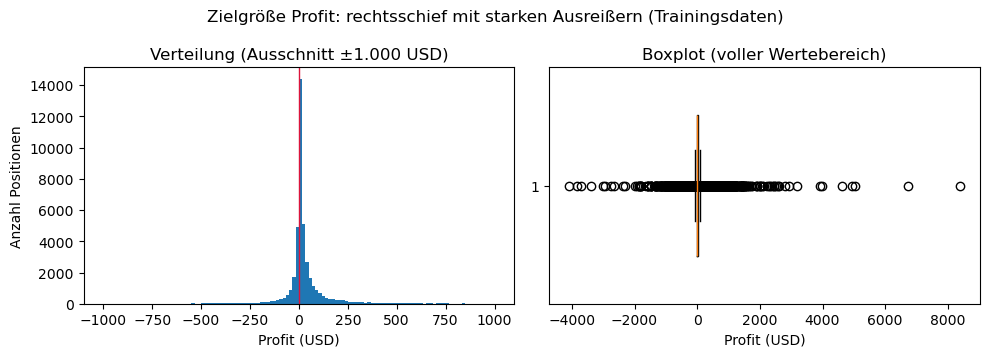

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(train_df["Profit"], bins=120, range=(-1000, 1000), color="#1f77b4")
axes[0].axvline(0, color="crimson", lw=1)
axes[0].set_xlabel("Profit (USD)"); axes[0].set_ylabel("Anzahl Positionen")
axes[0].set_title("Verteilung (Ausschnitt ±1.000 USD)")

axes[1].boxplot(train_df["Profit"], vert=False, widths=0.6)
axes[1].set_xlabel("Profit (USD)"); axes[1].set_title("Boxplot (voller Wertebereich)")
fig.suptitle("Zielgröße Profit: rechtsschief mit starken Ausreißern (Trainingsdaten)")
fig.tight_layout(); fig.savefig(f"{FIG}/abb0_zielverteilung.png", dpi=150)
plt.show()


In [12]:
# Korrelationen der metrischen Merkmale mit der Zielgröße
train_df[["Sales", "Quantity", "Discount", "Shipping Cost",
          "shipping_days", "unit_price", "Profit"]].corr().round(3)

,Sales,Quantity,Discount,Shipping Cost,shipping_days,unit_price,Profit
Sales,1.000,0.303,-0.085,0.762,-0.005,0.814,0.502
Quantity,0.303,1.000,-0.020,0.265,0.002,-0.014,0.105
Discount,-0.085,-0.020,1.000,-0.080,-0.004,-0.113,-0.316
Shipping Cost,0.762,0.265,-0.080,1.000,-0.144,0.630,0.372
shipping_days,-0.005,0.002,-0.004,-0.144,1.000,-0.005,0.004
unit_price,0.814,-0.014,-0.113,0.630,-0.005,1.000,0.432
Profit,0.502,0.105,-0.316,0.372,0.004,0.432,1.000


In [13]:
# Rabatt auf 3 Stellen runden: der Rohdatensatz enthält Gleitkomma-Dubletten
# (z. B. 0.15 und 0.15000000000000002), die jede Gruppierung sonst künstlich aufspalten.
train_df["Discount"] = train_df["Discount"].round(3)

# Mittlerer Profit je EXAKTER Rabattstufe (nur Stufen mit mindestens 100 Beobachtungen)
stufen = train_df.groupby("Discount")["Profit"].agg(["mean", "count"]).round(2)
stufen = stufen[stufen["count"] >= 100]
stufen

,mean,count
Discount,,
0.000,61.02,23255
0.002,119.84,358
0.070,124.52,121
0.100,64.60,3240
0.150,50.30,428
0.170,37.32,576
0.200,24.47,4019
0.250,9.62,159
0.270,-2.75,309


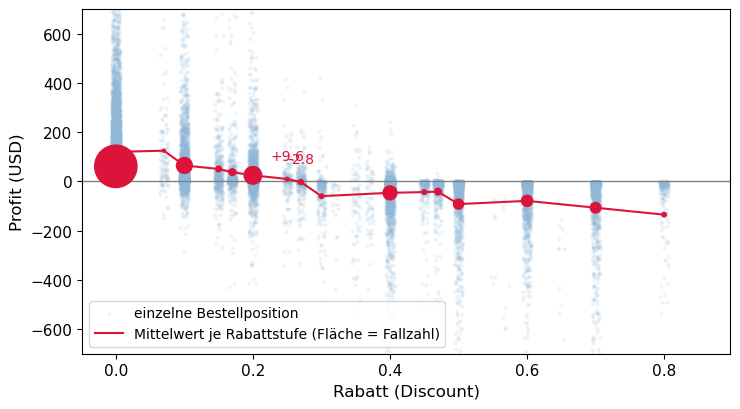

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
# Streudiagramm im Hintergrund (jitter, damit die diskreten Stufen nicht überdecken)
ax.scatter(train_df["Discount"] + np.random.uniform(-0.006, 0.006, len(train_df)),
           train_df["Profit"], s=4, alpha=0.10, color="#8fb8d8", label="einzelne Bestellposition")
ax.axhline(0, color="grey", lw=1)
# Mittelwert je exakter Rabattstufe; Punktfläche proportional zur Fallzahl
ax.scatter(stufen.index, stufen["mean"], s=stufen["count"]/25, color="crimson", zorder=3)
ax.plot(stufen.index, stufen["mean"], "-", color="crimson", lw=1.5, zorder=2,
        label="Mittelwert je Rabattstufe (Fläche = Fallzahl)")
for x in [0.25, 0.27]:
    ax.annotate(f"{stufen.loc[x,'mean']:+.1f}", (x, stufen.loc[x, "mean"]),
                textcoords="offset points", xytext=(0, 14), ha="center", color="crimson", fontsize=10)
ax.set_xlabel("Rabatt (Discount)", fontsize=12); ax.set_ylabel("Profit (USD)", fontsize=12)
ax.set_ylim(-700, 700); ax.tick_params(labelsize=11); ax.legend(loc="lower left", fontsize=10)
fig.tight_layout(); fig.savefig(f"{FIG}/abb1_discount_profit.png", dpi=150)
plt.show()


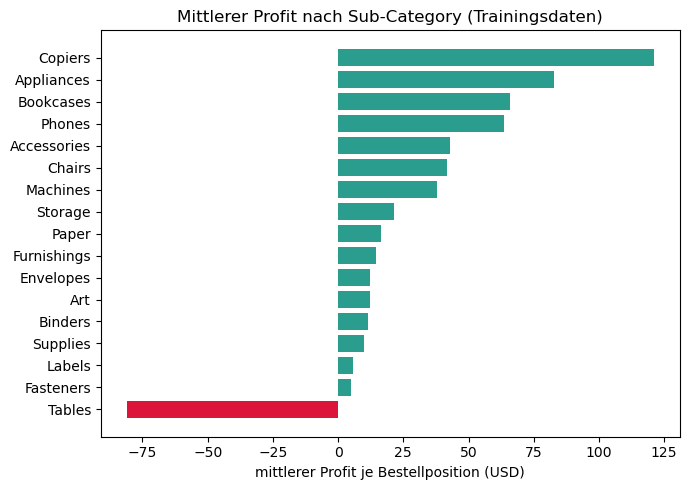

In [15]:
sub = train_df.groupby("Sub-Category")["Profit"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(sub.index, sub.values, color=["crimson" if v < 0 else "#2a9d8f" for v in sub.values])
ax.set_xlabel("mittlerer Profit je Bestellposition (USD)")
ax.set_title("Mittlerer Profit nach Sub-Category (Trainingsdaten)")
fig.tight_layout(); fig.savefig(f"{FIG}/abb2_subcategory_profit.png", dpi=150)
sub.round(2)
plt.show()


In [16]:
t = train_df[train_df["Sub-Category"] == "Tables"]
klassen = pd.cut(t["Discount"], [-0.01, 0.0, 0.2, 0.4, 0.6, 0.85])
t.groupby(klassen, observed=False)["Profit"].agg(["mean", "count"]).round(2)

,mean,count
Discount,,
"(-0.01, 0.0]",292.86,174
"(0.0, 0.2]",37.36,147
"(0.2, 0.4]",-170.44,196
"(0.4, 0.6]",-339.54,120
"(0.6, 0.85]",-644.95,60


In [17]:
# Profit nach Markt und nach Retouren-Status
print(train_df.groupby("Market")["Profit"].mean().round(2).sort_values(ascending=False), "\n")
print(train_df.groupby("returned")["Profit"].mean().round(2))

Market
Canada    46.55
APAC      40.51
EU        37.22
US        28.79
LATAM     20.80
Africa    18.42
EMEA       9.57
Name: Profit, dtype: float64 

returned
0    27.82
1    42.07
Name: Profit, dtype: float64


In [18]:
# ----------------------------------------------------------
#  TEIL 03 — Modellvergleich (3 Pipelines x 6 Algorithmen)
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
train_df = lade("train")

# Merkmale (X) und Zielgröße (y) sauber trennen:
# "Profit" ist die Zielgröße, "returned" ist Zukunftswissen -> beide raus aus X.
X_train = train_df.drop(columns=["Profit", "returned"])
y_train = train_df["Profit"].values

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_train.shape, y_train.shape

((41032, 27), (41032,))

In [19]:
# --- Merkmalsgruppen ---------------------------------------------------------
num_base = ["Sales", "Quantity", "Discount"]                       # Basis-Kennzahlen der Bestellung
num_ext  = ["Quantity", "Discount", "Shipping Cost", "shipping_days",
            "order_month", "order_year", "unit_price", "ship_cost_ratio"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]

# --- Pipeline A: Basis -------------------------------------------------------
# Median-Imputation (robust gegen Ausreißer) + Standardisierung; Kategorien als 0/1-Spalten
prep_A = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

# --- Pipeline B: Feature Engineering ----------------------------------------
# log1p(Sales) = log(1+Sales) staucht die schiefe Umsatzverteilung; dazu die abgeleiteten Merkmale
prep_B = ColumnTransformer([
    ("log", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("log", FunctionTransformer(np.log1p, validate=True)),
                      ("sc",  StandardScaler())]), ["Sales"]),
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_ext),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

# --- Pipeline C: Interaktionsterme ------------------------------------------
# PolynomialFeatures(2) erzeugt aus (Sales, Quantity, Discount) auch die Produkte,
# insbesondere Sales x Discount. Ökonomische Begründung:
#   Profit ~ Marge * Umsatz - Rabatteffekt * Umsatz
# Der Gewinn hängt also nicht additiv, sondern multiplikativ von Umsatz und Rabatt ab.
prep_C = ColumnTransformer([
    ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                      ("sc",   StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

pipelines = {"A_Basis": prep_A, "B_FeatEng": prep_B, "C_Interakt": prep_C}

In [20]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(alpha=1.0),                 # L2-Regularisierung
    "Lasso":            Lasso(alpha=1.0),                 # L1: kann Koeffizienten auf 0 setzen
    "kNN":              KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "DecisionTree":     DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    # Screening mit einem kleinen Wald — sparse_output=False oben sorgt für dichte Matrizen
    "RandomForest":     RandomForestRegressor(n_estimators=50, max_depth=12,
                                              random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
for pname, prep in pipelines.items():
    for mname, model in models.items():
        pipe = Pipeline([("prep", prep), ("model", model)])
        s = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")
        rows.append({"Pipeline": pname, "Modell": mname,
                     "CV_R2_Mittel": round(s.mean(), 4),
                     "CV_R2_Std": round(s.std(), 4)})       # Streuung zwischen den 5 Folds
        print(f"{pname:12s} {mname:17s} R2 = {s.mean():.4f}  (± {s.std():.4f})")

cv_table = pd.DataFrame(rows).sort_values("CV_R2_Mittel", ascending=False)
cv_table.to_csv(f"{RES}/cv_vergleich.csv", index=False)
cv_table

A_Basis      LinearRegression  R2 = 0.3385  (± 0.1132)


A_Basis      Ridge             R2 = 0.3387  (± 0.1130)


A_Basis      Lasso             R2 = 0.3343  (± 0.1014)


A_Basis      kNN               R2 = 0.5371  (± 0.1165)


A_Basis      DecisionTree      R2 = 0.5615  (± 0.1614)


...

C_Interakt   Lasso             R2 = 0.7098  (± 0.0449)


C_Interakt   kNN               R2 = 0.6446  (± 0.0561)


C_Interakt   DecisionTree      R2 = 0.5493  (± 0.1990)


C_Interakt   RandomForest      R2 = 0.6873  (± 0.0770)


,Pipeline,Modell,CV_R2_Mittel,CV_R2_Std
13,C_Interakt,Ridge,0.7144,0.0446
12,C_Interakt,LinearRegression,0.7141,0.0444
14,C_Interakt,Lasso,0.7098,0.0449
5,A_Basis,RandomForest,0.6991,0.0703
17,C_Interakt,RandomForest,0.6873,0.0770
11,B_FeatEng,RandomForest,0.6869,0.0727
15,C_Interakt,kNN,0.6446,0.0561
10,B_FeatEng,DecisionTree,0.5655,0.1651
4,A_Basis,DecisionTree,0.5615,0.1614
16,C_Interakt,DecisionTree,0.5493,0.1990


In [21]:
# ----------------------------------------------------------
#  TEIL 04 — Hyperparameter-Tuning
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
train_df = lade("train")
X_train = train_df.drop(columns=["Profit", "returned"])
y_train = train_df["Profit"].values
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Beste Pipeline aus Notebook 03: Interaktionsterme
num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
prep_C = ColumnTransformer([
    ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                      ("sc",   StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

In [22]:
grids = {
    "Ridge":        (Ridge(),               {"model__alpha": [0.01, 1, 100, 1000, 10000, 100000]}),
    "kNN":          (KNeighborsRegressor(), {"model__n_neighbors": [3, 5, 10, 20, 40]}),
    "RandomForest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                                            {"model__n_estimators": [100],
                                             "model__max_depth": [8, 12]}),
}

tuned, suchlaeufe = {}, {}
for name, (model, grid) in grids.items():
    gs = GridSearchCV(Pipeline([("prep", prep_C), ("model", model)]),
                      grid, cv=kf, scoring="r2")
    gs.fit(X_train, y_train)
    tuned[name] = {"best_params": {k.replace("model__", ""): v for k, v in gs.best_params_.items()},
                   "cv_r2": round(float(gs.best_score_), 4)}
    suchlaeufe[name] = gs
    print(name, tuned[name])

with open(f"{RES}/tuned_params.json", "w") as f:
    json.dump(tuned, f, indent=2)

Ridge {'best_params': {'alpha': 0.01}, 'cv_r2': 0.7144}


kNN {'best_params': {'n_neighbors': 10}, 'cv_r2': 0.6513}


RandomForest {'best_params': {'max_depth': 12, 'n_estimators': 100}, 'cv_r2': 0.6915}


In [23]:
# Wie wirkt die Regularisierungsstärke alpha? Ergebnisse aus der Suche oben
pd.DataFrame({"alpha": [0.01, 1, 100, 1000, 10000, 100000],
              "CV_R2": suchlaeufe["Ridge"].cv_results_["mean_test_score"].round(4)})

,alpha,CV_R2
0,0.01,0.7144
1,1.00,0.7144
2,100.00,0.7142
3,1000.00,0.7061
4,10000.00,0.6084
5,100000.00,0.2949


In [24]:
# ----------------------------------------------------------
#  TEIL 05 — Overfitting-Analyse
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
train_df = lade("train")
X_train = train_df.drop(columns=["Profit", "returned"])
y_train = train_df["Profit"].values
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
prep_C = ColumnTransformer([
    ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                      ("sc",   StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

In [25]:
depth_curve = {}
for d in [2, 4, 6, 8, 10, 14, 20]:
    p = Pipeline([("prep", prep_C), ("model", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    cvs = cross_val_score(p, X_train, y_train, cv=kf, scoring="r2")   # Validierungsgüte
    p.fit(X_train, y_train)                                            # Trainingsgüte
    depth_curve[d] = {"train": round(p.score(X_train, y_train), 4),
                      "cv": round(cvs.mean(), 4), "cv_std": round(cvs.std(), 4)}
    print(f"max_depth={d:2d}  train={depth_curve[d]['train']:.4f}  cv={depth_curve[d]['cv']:.4f}")
pd.DataFrame(depth_curve).T

max_depth= 2  train=0.3167  cv=0.1209


max_depth= 4  train=0.6735  cv=0.4313


max_depth= 6  train=0.7816  cv=0.5493


max_depth= 8  train=0.8286  cv=0.5618


max_depth=10  train=0.8693  cv=0.5411


max_depth=14  train=0.9303  cv=0.4671


max_depth=20  train=0.9769  cv=0.4245


,train,cv,cv_std
2,0.3167,0.1209,0.1543
4,0.6735,0.4313,0.1943
6,0.7816,0.5493,0.1990
8,0.8286,0.5618,0.2001
10,0.8693,0.5411,0.1860
14,0.9303,0.4671,0.1836
20,0.9769,0.4245,0.2041


Maximum bei Tiefe 8 (R²=0.5618 ± 0.2001)
1-SE-Regel -> sparsamste vertretbare Tiefe: 4


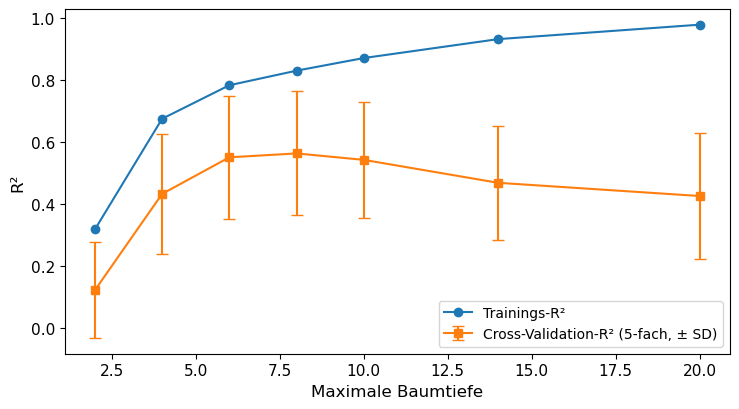

In [26]:
ds = sorted(depth_curve)
mw  = np.array([depth_curve[d]["cv"] for d in ds])
sd  = np.array([depth_curve[d]["cv_std"] for d in ds])

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(ds, [depth_curve[d]["train"] for d in ds], "o-", label="Trainings-R²")
ax.errorbar(ds, mw, yerr=sd, fmt="s-", capsize=4, label="Cross-Validation-R² (5-fach, ± SD)")
ax.set_xlabel("Maximale Baumtiefe", fontsize=12); ax.set_ylabel("R²", fontsize=12)
ax.tick_params(labelsize=11); ax.legend(fontsize=10)
fig.tight_layout(); fig.savefig(f"{FIG}/abb3_overfitting_baumtiefe.png", dpi=150)

# 1-SE-Regel: einfachstes Modell, dessen CV-Score innerhalb einer Standardabweichung des Maximums liegt
best = int(np.argmax(mw)); schwelle = mw[best] - sd[best]
sparsam = [d for d, m in zip(ds, mw) if m >= schwelle][0]
print(f"Maximum bei Tiefe {ds[best]} (R²={mw[best]:.4f} ± {sd[best]:.4f})")
print(f"1-SE-Regel -> sparsamste vertretbare Tiefe: {sparsam}")

import json
tuned = json.load(open(f"{RES}/tuned_params.json"))
tuned["DecisionTree"] = {"best_params": {"max_depth": int(ds[best])}, "cv_r2": float(mw[best]),
                         "hinweis_1SE": int(sparsam)}
json.dump(tuned, open(f"{RES}/tuned_params.json", "w"), indent=2)
pd.DataFrame(depth_curve).T.to_csv(f"{RES}/overfitting_baumtiefe.csv")
plt.show()


In [27]:
# ----------------------------------------------------------
#  TEIL 06 — Finale Evaluation auf den Testdaten
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
train_df = lade("train")
test_df  = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
tuned = json.load(open(f"{RES}/tuned_params.json"))

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def make_prep_C():
    """Pipeline C (Interaktionsterme) — als Funktion, damit jedes Modell eine frische Kopie bekommt."""
    return ColumnTransformer([
        ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                          ("sc",   StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

In [28]:
models = {
    "Mittelwert-Baseline": (DummyRegressor(strategy="mean"), "dummy"),
    "Nur Sales+Discount":  (LinearRegression(), "minimal"),
    "LinearRegression":    (LinearRegression(), "C"),
    "Ridge":               (Ridge(**tuned["Ridge"]["best_params"]), "C"),
    "kNN":                 (KNeighborsRegressor(**tuned["kNN"]["best_params"]), "C"),
    "DecisionTree":        (DecisionTreeRegressor(random_state=RANDOM_STATE, **tuned["DecisionTree"]["best_params"]), "C"),
    "RandomForest":        (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **tuned["RandomForest"]["best_params"]), "C"),
}

# minimale Pipeline: nur Sales und Discount, mit Interaktionsterm, ohne Kategorien
prep_min = ColumnTransformer([("num", Pipeline([("poly", PolynomialFeatures(2, include_bias=False)),
                                                ("sc", StandardScaler())]), ["Sales", "Discount"])])

rows, preds = [], {}
for name, (model, kind) in models.items():
    prep = "passthrough" if kind == "dummy" else (prep_min if kind == "minimal" else make_prep_C())
    steps = [("model", model)] if kind == "dummy" else [("prep", prep), ("model", model)]
    p = Pipeline(steps).fit(X_train if kind != "dummy" else X_train[num_base], y_train)
    pred = p.predict(X_test if kind != "dummy" else X_test[num_base])
    preds[name] = pred
    rows.append({"Modell": name,
                 "Test_R2":   round(r2_score(y_test, pred), 4),
                 "Test_RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 2),
                 "Test_MAE":  round(mean_absolute_error(y_test, pred), 2)})

final = pd.DataFrame(rows).sort_values("Test_R2", ascending=False).reset_index(drop=True)
final.to_csv(f"{RES}/test_scores.csv", index=False)
final

,Modell,Test_R2,Test_RMSE,Test_MAE
0,LinearRegression,0.6631,100.20,41.04
1,Ridge,0.6631,100.20,41.03
2,Nur Sales+Discount,0.6602,100.63,40.21
3,RandomForest,0.6538,101.58,35.81
4,kNN,0.6367,104.05,39.94
5,DecisionTree,0.6069,108.24,38.01
6,Mittelwert-Baseline,-0.0000,172.63,67.52


In [29]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

full = lade("gs_clean")
Xf = full.drop(columns=["Profit", "returned"]); yf = full["Profit"].values

def evaluate(tr_idx, te_idx, label):
    out = {"Split": label}
    for mname, model in [("LinearRegression", LinearRegression()),
                         ("RandomForest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                                                                **tuned["RandomForest"]["best_params"]))]:
        p = Pipeline([("prep", make_prep_C()), ("model", model)]).fit(Xf.iloc[tr_idx], yf[tr_idx])
        out[mname] = round(r2_score(yf[te_idx], p.predict(Xf.iloc[te_idx])), 4)
    return out

rob = []
# (a) zufälliger Split je Zeile — das Design der Hauptanalyse
from sklearn.model_selection import train_test_split as tts
idx_tr, idx_te = tts(np.arange(len(full)), test_size=0.2, random_state=RANDOM_STATE)
rob.append(evaluate(idx_tr, idx_te, "zufällig je Zeile (Hauptanalyse)"))

# (b) gruppierter Split nach Order ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
g_tr, g_te = next(gss.split(Xf, yf, groups=full["Order ID"]))
rob.append(evaluate(g_tr, g_te, "gruppiert nach Order ID"))

# (c) zeitlicher Split: 2011-2013 -> 2014
t_tr = np.where(full["order_year"] <= 2013)[0]
t_te = np.where(full["order_year"] == 2014)[0]
rob.append(evaluate(t_tr, t_te, "zeitlich 2011-2013 -> 2014"))

rob_df = pd.DataFrame(rob)
rob_df.to_csv(f"{RES}/robustheit_splits.csv", index=False)
rob_df

,Split,LinearRegression,RandomForest
0,zufällig je Zeile (Hauptanalyse),0.6631,0.6538
1,gruppiert nach Order ID,0.6448,0.6844
2,zeitlich 2011-2013 -> 2014,0.7192,0.7549


In [30]:
best_name = final.iloc[0]["Modell"] if final.iloc[0]["Modell"] not in ("Mittelwert-Baseline",) else "LinearRegression"
best_model = models[best_name][0]
pipe_best = Pipeline([("prep", make_prep_C()), ("model", best_model)]).fit(X_train, y_train)

r = permutation_importance(pipe_best, X_test, y_test, n_repeats=5,
                           random_state=RANDOM_STATE, scoring="r2", n_jobs=1)
imp = (pd.DataFrame({"Merkmal": X_test.columns, "Wichtigkeit": r.importances_mean})
         .sort_values("Wichtigkeit", ascending=False).head(10))
imp.round(4)

,Merkmal,Wichtigkeit
14,Category,1.489697e+22
15,Sub-Category,1.489697e+22
19,Discount,1.446700e+00
17,Sales,1.352000e+00
18,Quantity,1.680000e-02
11,Market,1.500000e-03
7,Segment,1.000000e-04
4,Ship Mode,0.000000e+00
0,Row ID,0.000000e+00
25,unit_price,0.000000e+00


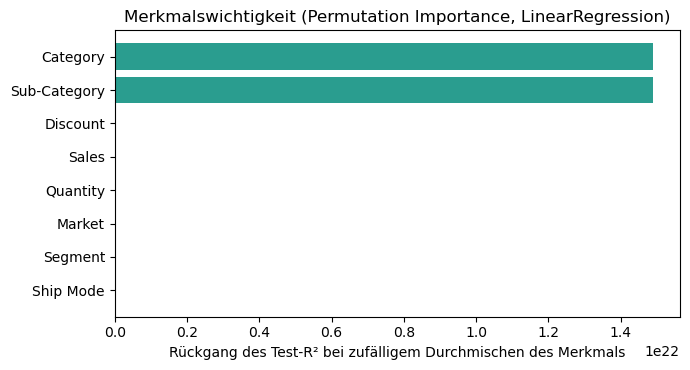

In [31]:
top = imp.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(top["Merkmal"], top["Wichtigkeit"], color="#2a9d8f")
ax.set_xlabel("Rückgang des Test-R² bei zufälligem Durchmischen des Merkmals")
ax.set_title(f"Merkmalswichtigkeit (Permutation Importance, {best_name})")
fig.tight_layout(); fig.savefig(f"{FIG}/abb5_merkmalswichtigkeit.png", dpi=150)
plt.show()


In [32]:
num_ohne_sales = ["Quantity", "Discount", "Shipping Cost"]
prep_ohne = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(2, include_bias=False)),
                      ("sc", StandardScaler())]), num_ohne_sales),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

p = Pipeline([("prep", prep_ohne), ("model", LinearRegression())]).fit(X_train, y_train)
pred = p.predict(X_test)
print("Ohne Sales -> Test-R²:", round(r2_score(y_test, pred), 4),
      "| MAE:", round(mean_absolute_error(y_test, pred), 2), "USD")

Ohne Sales -> Test-R²: 0.49 | MAE: 49.49 USD


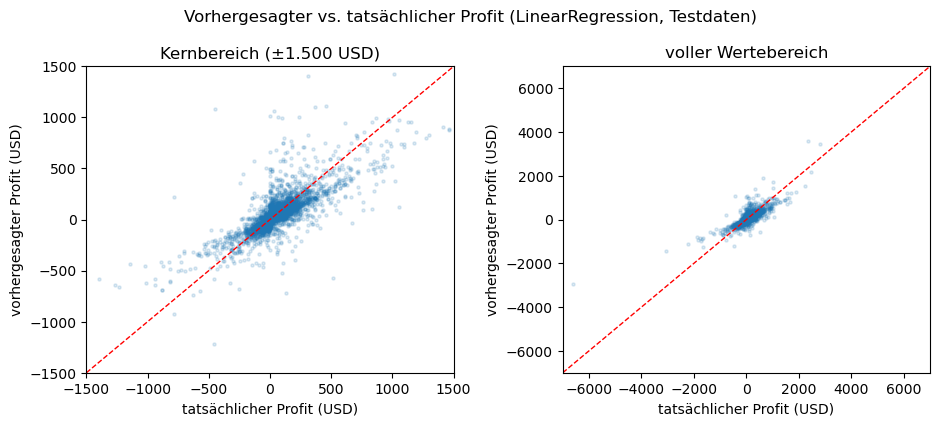

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3))
pb = preds[best_name]
for ax, lim, title in [(axes[0], 1500, "Kernbereich (±1.500 USD)"),
                       (axes[1], 7000, "voller Wertebereich")]:
    ax.scatter(y_test, pb, s=5, alpha=0.15, color="#1f77b4")
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("tatsächlicher Profit (USD)"); ax.set_ylabel("vorhergesagter Profit (USD)")
    ax.set_title(title)
fig.suptitle(f"Vorhergesagter vs. tatsächlicher Profit ({best_name}, Testdaten)")
fig.tight_layout(); fig.savefig(f"{FIG}/abb4_pred_vs_actual.png", dpi=150)
plt.show()


In [34]:
# ----------------------------------------------------------
#  TEIL 07 — Struktur der Zielgroesse
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
train_df = lade("train"); test_df = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def prep_C(grad=2):
    """Pipeline C mit wählbarem Polynomgrad — der Grad ist selbst ein Hyperparameter."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=grad, include_bias=False)),
                          ("sc", StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
def güte(y, p):
    return {"R2": round(r2_score(y, p), 4), "RMSE": round(float(np.sqrt(mean_squared_error(y, p))), 2),
            "MAE": round(mean_absolute_error(y, p), 2)}

In [35]:
# implizite Basismarge je Zeile zurückrechnen
t = train_df.copy()
t["m_impl"] = (t["Profit"] / t["Sales"]) * (1 - t["Discount"]) + t["Discount"]

sd_innerhalb = t.groupby("Product ID")["m_impl"].std().mean()   # Streuung innerhalb eines Produkts
sd_gesamt    = t["m_impl"].std()                                 # Streuung über alle Produkte
print(f"Standardabweichung der Basismarge INNERHALB eines Produkts: {sd_innerhalb:.4f}")
print(f"Standardabweichung der Basismarge ÜBER ALLE Produkte:      {sd_gesamt:.4f}")
print(f"Median der Basismarge: {t['m_impl'].median():.4f}")

Standardabweichung der Basismarge INNERHALB eines Produkts: 0.0040
Standardabweichung der Basismarge ÜBER ALLE Produkte:      0.1490
Median der Basismarge: 0.2700


In [36]:
# Geschlossene Formel als Vergleichsmaßstab — die Marge wird NUR aus den Trainingsdaten geschätzt
m_je_produkt = t.groupby("Product ID")["m_impl"].median()
m_global     = float(t["m_impl"].median())

def formel(D, marge_map=None):
    m = m_global if marge_map is None else D["Product ID"].map(marge_map).fillna(m_global)
    return (D["Sales"] * (m - D["Discount"]) / (1 - D["Discount"])).values

vergleich = pd.DataFrame([
    {"Verfahren": "Formel, eine globale Marge (0 gefittete Parameter)", **güte(y_test, formel(test_df))},
    {"Verfahren": "Formel, Marge je Produkt",                          **güte(y_test, formel(test_df, m_je_produkt))},
])
print("Anteil im Test unbekannter Produkte:",
      round(test_df["Product ID"].map(m_je_produkt).isna().mean(), 4))
vergleich

Anteil im Test unbekannter Produkte: 0.0398


,Verfahren,R2,RMSE,MAE
0,"Formel, eine globale Marge (0 gefittete Parame...",0.7358,88.73,36.13
1,"Formel, Marge je Produkt",0.9735,28.12,3.71


In [37]:
folds = {}
for grad in [1, 2, 3]:
    s = cross_val_score(Pipeline([("prep", prep_C(grad)), ("m", LinearRegression())]),
                        X_train, y_train, cv=kf, scoring="r2")
    folds[grad] = s
    print(f"Polynomgrad {grad}: CV-R² = {s.mean():.4f} (± {s.std():.4f})")

from scipy import stats
t_stat, p_wert = stats.ttest_rel(folds[3], folds[2])      # gepaart über dieselben Folds
print(f"\nGrad 3 vs. Grad 2: Delta = {folds[3].mean()-folds[2].mean():+.4f}, p = {p_wert:.4f}")

Polynomgrad 1: CV-R² = 0.3387 (± 0.1130)


Polynomgrad 2: CV-R² = 0.7141 (± 0.0444)


Polynomgrad 3: CV-R² = 0.7478 (± 0.0341)

Grad 3 vs. Grad 2: Delta = +0.0337, p = 0.0062


In [38]:
p3 = Pipeline([("prep", prep_C(3)), ("m", LinearRegression())]).fit(X_train, y_train)
print("Polynomgrad 3 auf den Testdaten:", güte(y_test, p3.predict(X_test)))

Polynomgrad 3 auf den Testdaten: {'R2': 0.7152, 'RMSE': 92.13, 'MAE': 37.44}


In [39]:
marge_train = (train_df["Profit"] / train_df["Sales"]).values
zeilen = []
for name, modell in [("Lineare Regression", LinearRegression()),
                     ("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=12,
                                                             random_state=RANDOM_STATE, n_jobs=-1))]:
    p = Pipeline([("prep", prep_C(2)), ("m", modell)]).fit(X_train, marge_train)
    pred = p.predict(X_test) * test_df["Sales"].values      # Rücktransformation
    zeilen.append({"Modell (Zielgröße Marge)": name, **güte(y_test, pred)})
marge_tab = pd.DataFrame(zeilen)
marge_tab.to_csv(f"{RES}/marge_modellierung.csv", index=False)
marge_tab

,Modell (Zielgröße Marge),R2,RMSE,MAE
0,Lineare Regression,0.7200,91.34,36.27
1,Random Forest,0.7472,86.79,34.11


In [40]:
# ----------------------------------------------------------
#  TEIL 08 — Statistische Belastbarkeit
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
train_df = lade("train"); test_df = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def prep_C(grad=2):
    """Pipeline C mit wählbarem Polynomgrad — der Grad ist selbst ein Hyperparameter."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=grad, include_bias=False)),
                          ("sc", StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
def güte(y, p):
    return {"R2": round(r2_score(y, p), 4), "RMSE": round(float(np.sqrt(mean_squared_error(y, p))), 2),
            "MAE": round(mean_absolute_error(y, p), 2)}

In [41]:
from scipy import stats
f_lin = cross_val_score(Pipeline([("prep", prep_C(2)), ("m", LinearRegression())]),
                        X_train, y_train, cv=kf, scoring="r2")
f_rf  = cross_val_score(Pipeline([("prep", prep_C(2)), ("m", RandomForestRegressor(
                            n_estimators=60, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]),
                        X_train, y_train, cv=kf, scoring="r2")
t_stat, p_wert = stats.ttest_rel(f_lin, f_rf)
print("Folds linear:      ", np.round(f_lin, 4))
print("Folds RandomForest:", np.round(f_rf, 4))
print(f"Delta = {f_lin.mean()-f_rf.mean():+.4f}   p = {p_wert:.4f}  ->",
      "nicht signifikant" if p_wert > 0.05 else "signifikant")

Folds linear:       [0.744  0.7289 0.7588 0.6324 0.7062]
Folds RandomForest: [0.7662 0.7524 0.6992 0.6715 0.5495]
Delta = +0.0263   p = 0.5147  -> nicht signifikant


In [42]:
# Bootstrap auf den Testdaten: wie sicher ist der Unterschied dort?
pred_lin = Pipeline([("prep", prep_C(2)), ("m", LinearRegression())]).fit(X_train, y_train).predict(X_test)
pred_rf  = Pipeline([("prep", prep_C(2)), ("m", RandomForestRegressor(
               n_estimators=60, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]).fit(X_train, y_train).predict(X_test)

rng = np.random.default_rng(RANDOM_STATE); n = len(y_test)
d_r2, d_mae = [], []
for _ in range(300):
    i = rng.integers(0, n, n)
    d_r2.append(r2_score(y_test[i], pred_lin[i]) - r2_score(y_test[i], pred_rf[i]))
    d_mae.append(mean_absolute_error(y_test[i], pred_lin[i]) - mean_absolute_error(y_test[i], pred_rf[i]))
print(f"Delta R²  = {np.mean(d_r2):+.4f}   95%-KI [{np.percentile(d_r2,2.5):+.4f}; {np.percentile(d_r2,97.5):+.4f}]")
print(f"Delta MAE = {np.mean(d_mae):+.2f} USD  95%-KI [{np.percentile(d_mae,2.5):+.2f}; {np.percentile(d_mae,97.5):+.2f}]")

Delta R²  = +0.0070   95%-KI [-0.0322; +0.0670]
Delta MAE = +5.26 USD  95%-KI [+4.28; +5.96]


In [43]:
# ----------------------------------------------------------
#  TEIL 09 — Diagnostik und Anwendungsfall
# ----------------------------------------------------------

def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
train_df = lade("train"); test_df = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def prep_C(grad=2):
    """Pipeline C mit wählbarem Polynomgrad — der Grad ist selbst ein Hyperparameter."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=grad, include_bias=False)),
                          ("sc", StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
def güte(y, p):
    return {"R2": round(r2_score(y, p), 4), "RMSE": round(float(np.sqrt(mean_squared_error(y, p))), 2),
            "MAE": round(mean_absolute_error(y, p), 2)}

In [44]:
# Vorhersagen der beiden Hauptmodelle erzeugen (werden unten gebraucht)
pred_lin = Pipeline([("prep", prep_C(2)), ("m", LinearRegression())]).fit(X_train, y_train).predict(X_test)
pred_rf  = Pipeline([("prep", prep_C(2)), ("m", RandomForestRegressor(
               n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]).fit(X_train, y_train).predict(X_test)
from scipy import stats
print("Vorhersagen berechnet.")

Vorhersagen berechnet.


Korrelation |Residuum| mit Sales: 0.74
Schiefe der Residuen: -6.58


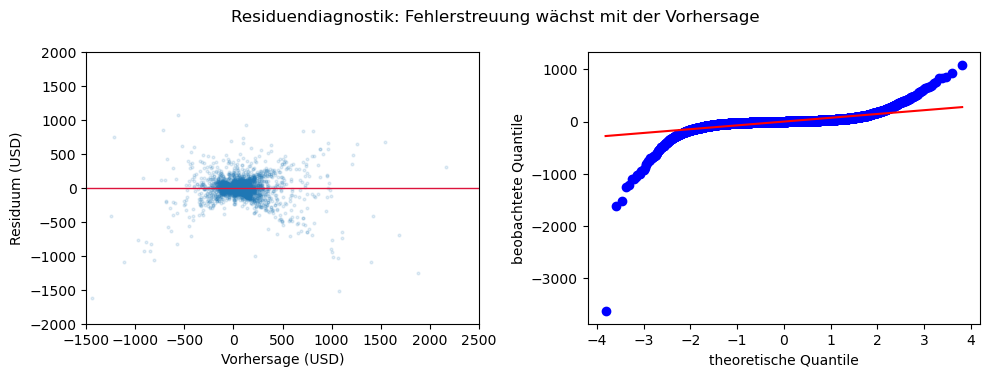

In [45]:
res = y_test - pred_lin
print("Korrelation |Residuum| mit Sales:", round(np.corrcoef(np.abs(res), test_df["Sales"])[0,1], 3))
print("Schiefe der Residuen:", round(float(stats.skew(res)), 2))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].scatter(pred_lin, res, s=4, alpha=0.12, color="#1f77b4"); ax[0].axhline(0, color="crimson", lw=1)
ax[0].set_xlim(-1500, 2500); ax[0].set_ylim(-2000, 2000)
ax[0].set_xlabel("Vorhersage (USD)"); ax[0].set_ylabel("Residuum (USD)")
stats.probplot(res, plot=ax[1]); ax[1].set_title("")
ax[1].set_xlabel("theoretische Quantile"); ax[1].set_ylabel("beobachtete Quantile")
fig.suptitle("Residuendiagnostik: Fehlerstreuung wächst mit der Vorhersage")
fig.tight_layout(); fig.savefig(f"{FIG}/abb4_residuen.png", dpi=150)
plt.show()


In [46]:
seg = (test_df.assign(Fehler=np.abs(res))
       .groupby("Category")["Fehler"].agg(["mean", "median", "count"]).round(1)
       .rename(columns={"mean": "MAE", "median": "Median-Fehler", "count": "n"}))
seg.to_csv(f"{RES}/fehler_je_segment.csv")
seg

,MAE,Median-Fehler,n
Category,,,
Furniture,63.1,27.9,1960
Office Supplies,24.1,12.2,6235
Technology,71.3,32.1,2063


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

ist_verlust = y_test < 0
kandidaten = {
    "Regression, linear (Notebook 06)": pred_lin < 0,
    "Regression, Random Forest":        pred_rf  < 0,
    "Fachregel: Discount > 0,2":        (test_df["Discount"] > 0.2).values,
}
clf = Pipeline([("prep", prep_C(2)), ("m", LogisticRegression(max_iter=2000))]).fit(X_train, y_train < 0)
kandidaten["Logistische Regression"] = clf.predict(X_test)

warn = pd.DataFrame([{"Verfahren": k,
                      "Precision": round(precision_score(ist_verlust, v), 3),
                      "Recall":    round(recall_score(ist_verlust, v), 3),
                      "F1":        round(f1_score(ist_verlust, v), 3)} for k, v in kandidaten.items()])
warn.to_csv(f"{RES}/warnsystem_vergleich.csv", index=False)
print("Anteil Verlustpositionen im Testset:", round(ist_verlust.mean(), 3))
warn

Anteil Verlustpositionen im Testset: 0.249


,Verfahren,Precision,Recall,F1
0,"Regression, linear (Notebook 06)",0.739,0.697,0.717
1,"Regression, Random Forest",0.914,0.784,0.844
2,"Fachregel: Discount > 0,2",0.898,0.806,0.849
3,Logistische Regression,0.894,0.805,0.848
